### Importing all the packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from xgboost import XGBClassifier
import xgboost as xgb


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.utils.class_weight import compute_sample_weight

## Data Preparation 

### Read data into dataframe

In [2]:
# The file contains 144 lines of metadata/comments before the header row.
# skiprows=144 tells pandas to ignore the first 144 lines of the file.
original_data = pd.read_csv('cumulative_2025.11.30_09.22.58.csv', skiprows=144)

In [3]:
display(original_data)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10090151,K07985.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,-1.757,0.068,2.763,0.074,2.344,0.072,-1.756,0.068,2.929,0.072
9560,9561,10128825,K07986.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.497,0,...,-0.250,0.490,0.780,0.460,0.500,0.400,-0.180,0.470,0.530,0.470
9561,9562,10147276,K07987.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.021,0,...,-3.650,0.260,5.000,0.220,3.380,0.160,-3.890,0.260,5.160,0.220
9562,9563,10155286,K07988.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.092,0,...,1.320,0.670,1.690,0.530,1.450,0.110,1.370,0.660,2.000,0.460


In [4]:
original_data.shape

(9564, 141)

### Select target, features and drop unnecessary rows

In [5]:
# select target 
# select target before dealing with missing values to stop data leaking 

target = original_data[['koi_disposition']]

In [6]:
target.shape

(9564, 1)

In [7]:
features = original_data[[

    # Vetting flags
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",

    # Score
    "koi_score",

    # Transit / fit parameters
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_ror",
    "koi_sma",
    "koi_incl",
    "koi_impact",
    "koi_dor",

    # Strength / detection stats
    "koi_model_snr",
    "koi_max_sngle_ev",
    "koi_num_transits",

    # Stellar parameters
    "koi_steff",
    "koi_slogg",
    "koi_smet",
    "koi_srad",
    "koi_smass",
]]

In [8]:
features.shape

(9564, 22)

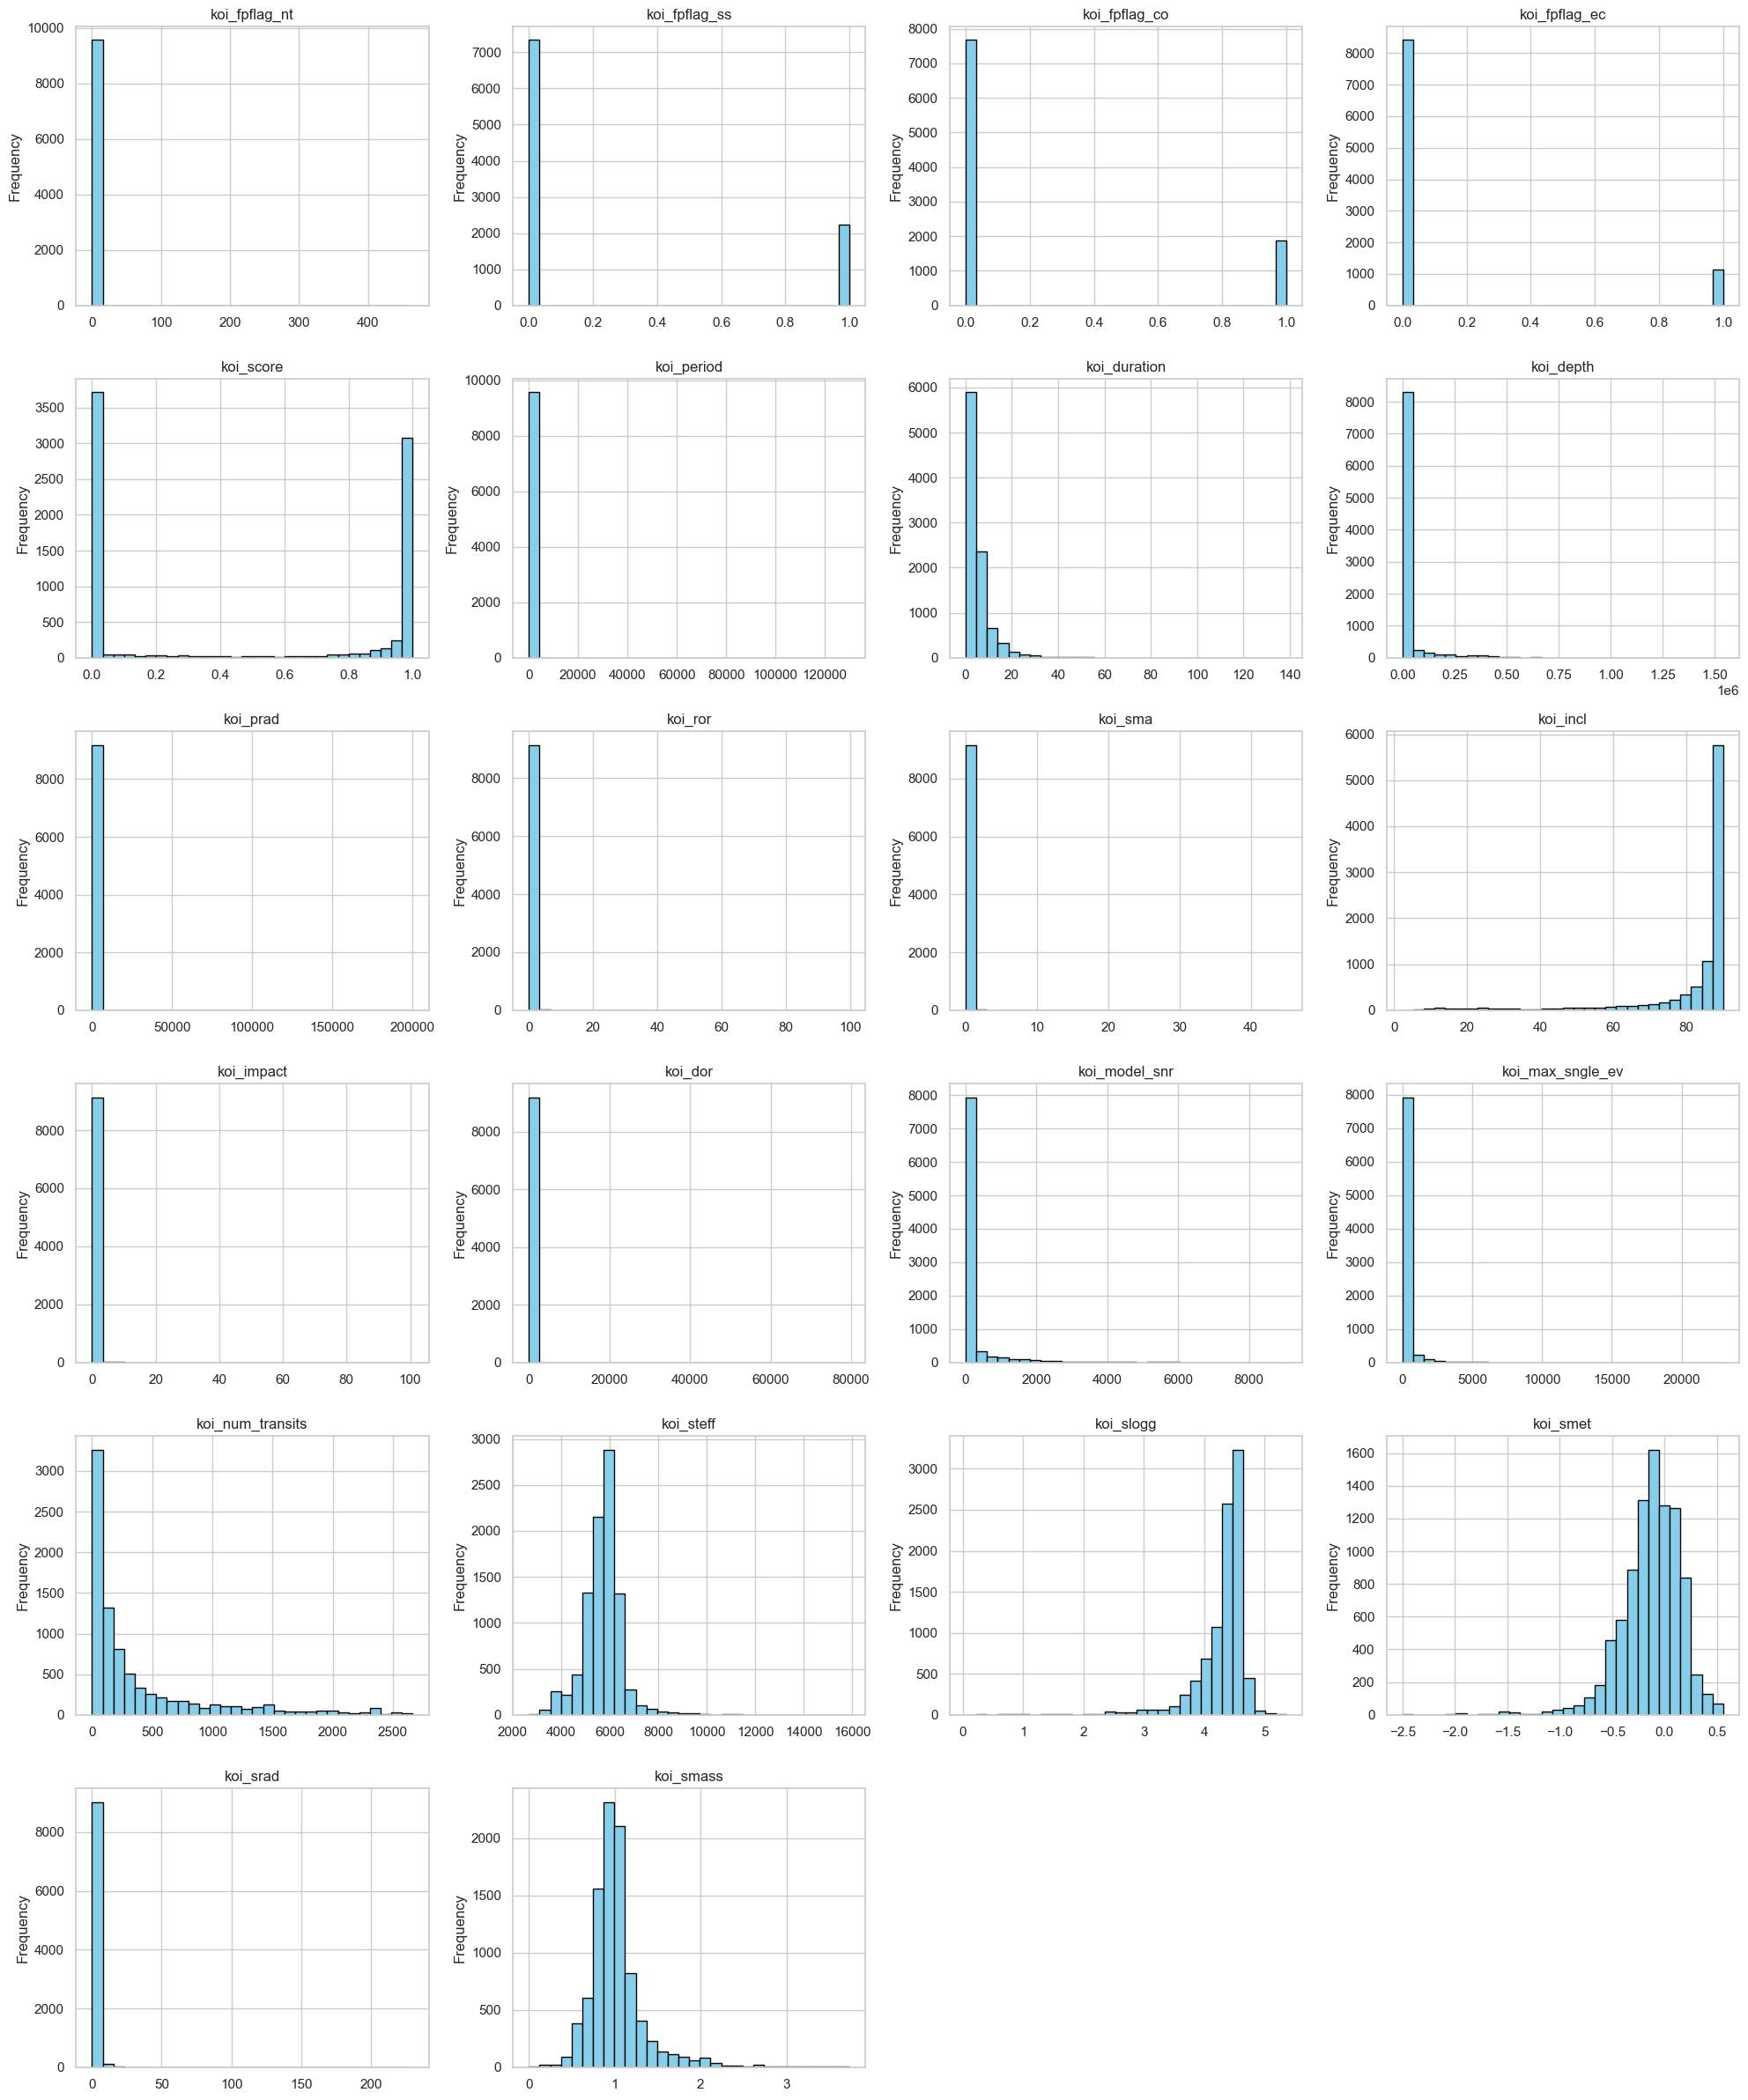

In [9]:
# Optional: switch to seaborn style for nicer plots
sns.set(style="whitegrid")

# Number of features
n_features = len(features.columns)

# Automatically choose number of columns/rows for subplots
n_cols = 4  # adjust if you want wider/narrower grid
n_rows = math.ceil(n_features / n_cols)

# Create figure
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

# Plot each feature
for i, col in enumerate(features.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    # Histogram
    plt.hist(features[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
    
plt.tight_layout()
plt.show()


In [96]:
# List of all numerical columns in your feature set that are candidates for missingness
numerical_imputation_candidates = [
    "koi_score", "koi_prad", "koi_ror", "koi_sma", "koi_incl", "koi_impact", "koi_dor", 
    "koi_model_snr", "koi_max_sngle_ev", "koi_num_transits", "koi_steff", "koi_slogg", 
    "koi_smet", "koi_srad", "koi_smass"
    # Note: koi_period, koi_depth, koi_duration are typically near-complete and may not need flags.
]

# --- 1. Create Indicator Flags Dynamically ---

# Store the names of the newly created flag columns for later use
new_missing_flag_cols = []

for col in numerical_imputation_candidates:
    # Check if the column contains any missing values
    if features[col].isnull().any():
        flag_name = f'is_{col}_missing'
        
        # Create the binary flag column (1 if missing, 0 otherwise)
        features[flag_name] = features[col].isnull().astype(int)
        new_missing_flag_cols.append(flag_name)

print(f"Created {len(new_missing_flag_cols)} missing indicator flags.")

Created 0 missing indicator flags.


### Identifying missing values 

In [11]:
#Find missing in targets
target.isnull().sum()

koi_disposition    0
dtype: int64

In [12]:
# Find missing values
features.isnull().sum()

koi_fpflag_nt                     0
koi_fpflag_ss                     0
koi_fpflag_co                     0
koi_fpflag_ec                     0
koi_score                      1510
koi_period                        0
koi_duration                      0
koi_depth                       363
koi_prad                        363
koi_ror                         363
koi_sma                         363
koi_incl                        364
koi_impact                      363
koi_dor                         363
koi_model_snr                   363
koi_max_sngle_ev               1142
koi_num_transits               1142
koi_steff                       363
koi_slogg                       363
koi_smet                        386
koi_srad                        363
koi_smass                       363
is_koi_score_missing              0
is_koi_prad_missing               0
is_koi_ror_missing                0
is_koi_sma_missing                0
is_koi_incl_missing               0
is_koi_impact_missing       

In [13]:
num_cols_with_missing_values = (features.isnull().sum() > 0).sum()
print(f"Number of columns with missing values: {num_cols_with_missing_values}")

Number of columns with missing values: 16


In [14]:
features_missing_values = [ "koi_score",
    "koi_depth",
    "koi_prad",
    "koi_ror",
    "koi_sma",
    "koi_incl",
    "koi_impact",
    "koi_dor",
    "koi_model_snr",
    "koi_max_sngle_ev",
    "koi_num_transits",
    "koi_steff",
    "koi_slogg",
    "koi_smet",
    "koi_srad",
    "koi_smass"]
print(features[features_missing_values].describe())

         koi_score     koi_depth       koi_prad      koi_ror      koi_sma  \
count  8054.000000  9.201000e+03    9201.000000  9201.000000  9201.000000   
mean      0.480829  2.379134e+04     102.891778     0.283646     0.223989   
std       0.476928  8.224268e+04    3077.639126     3.306558     0.566359   
min       0.000000  0.000000e+00       0.080000     0.001289     0.005900   
25%       0.000000  1.599000e+02       1.400000     0.012341     0.037700   
50%       0.334000  4.211000e+02       2.390000     0.021076     0.085100   
75%       0.998000  1.473400e+03      14.930000     0.095348     0.214400   
max       1.000000  1.541400e+06  200346.000000    99.870651    44.989200   

          koi_incl   koi_impact       koi_dor  koi_model_snr  \
count  9200.000000  9201.000000   9201.000000    9201.000000   
mean     82.469147     0.735105     76.736333     259.895001   
std      15.223627     3.348832    845.274598     795.806615   
min       2.290000     0.000000      0.373000     

### Look at outliers and decide on imputation method

These flags are a crucial best practice for dealing with missing data, especially in a specialized dataset like this. They are necessary to make your model as accurate as possible.

Why the Flags are Needed

When we fill in a missing value with the median, we are making an educated guess. The missing indicator flag (is_..._missing) is a binary column that tells the machine learning model:

"For this row, the value in koi_prad is imputed, so treat this data point with caution, because its original value was unknown."

The model can then learn whether KOIs with missing stellar properties are systematically more likely to be FALSE POSITIVE than those with complete stellar data.

Action: Create the Missing Indicator Flags

You must run the following code to create these three missing indicator columns. They should be created before the final scaling step, as they are binary (0s and 1s) and do not get scaled.

Note: You must run this code before you ran the median imputation on all the respective columns, as we need the original NaN values to create these flags. Since you said you've finished imputation, the safest assumption is that you need to re-identify where the data was missing if you haven't already saved a separate DataFrame.

In [15]:
# List of all numerical columns that are candidates for missingness
numerical_imputation_candidates = [ "koi_score",
    "koi_depth",
    "koi_prad",
    "koi_ror",
    "koi_sma",
    "koi_incl",
    "koi_impact",
    "koi_dor",
    "koi_model_snr",
    "koi_max_sngle_ev",
    "koi_num_transits",
    "koi_steff",
    "koi_slogg",
    "koi_smet",
    "koi_srad",
    "koi_smass"]

# This list will hold only the names of the flags that were actually created
new_missing_flag_cols = []

# --- 1. Create Missing Indicator Flags ---
for col in numerical_imputation_candidates:
    if features[col].isnull().any():
        flag_name = f'is_{col}_missing'
        features[flag_name] = features[col].isnull().astype(int)
        new_missing_flag_cols.append(flag_name)

print(f"✅ Created {len(new_missing_flag_cols)} missing indicator flags.")

# --- 2. Impute Original NaNs with the Median ---
for col in numerical_imputation_candidates:
    median_val = features[col].median()
    features.loc[:, col] = features[col].fillna(median_val)
    
print("✅ Imputation complete.")

✅ Created 16 missing indicator flags.
✅ Imputation complete.


/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/3214538061.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[flag_name] = features[col].isnull().astype(int)
/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/3214538061.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[flag_name] = features[col].isnull().astype(int)
/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/3214538061.py:26: SettingWithCopyWarning: 
A value is trying to be set on a

In [16]:
len(numerical_imputation_candidates)

16

In [17]:
# 1. Identify the log-transformed column with missing data
problem_col = 'koi_depth'

# 2. Calculate the median of the existing (non-missing) log-transformed values
median_log_depth = features[problem_col].median()

# 3. Safely impute the 363 missing values with the median
features.loc[:, problem_col] = features[problem_col].fillna(median_log_depth)

# Verification check
print(f"Missing values in {problem_col} after fix: {features[problem_col].isnull().sum()}")

Missing values in koi_depth after fix: 0


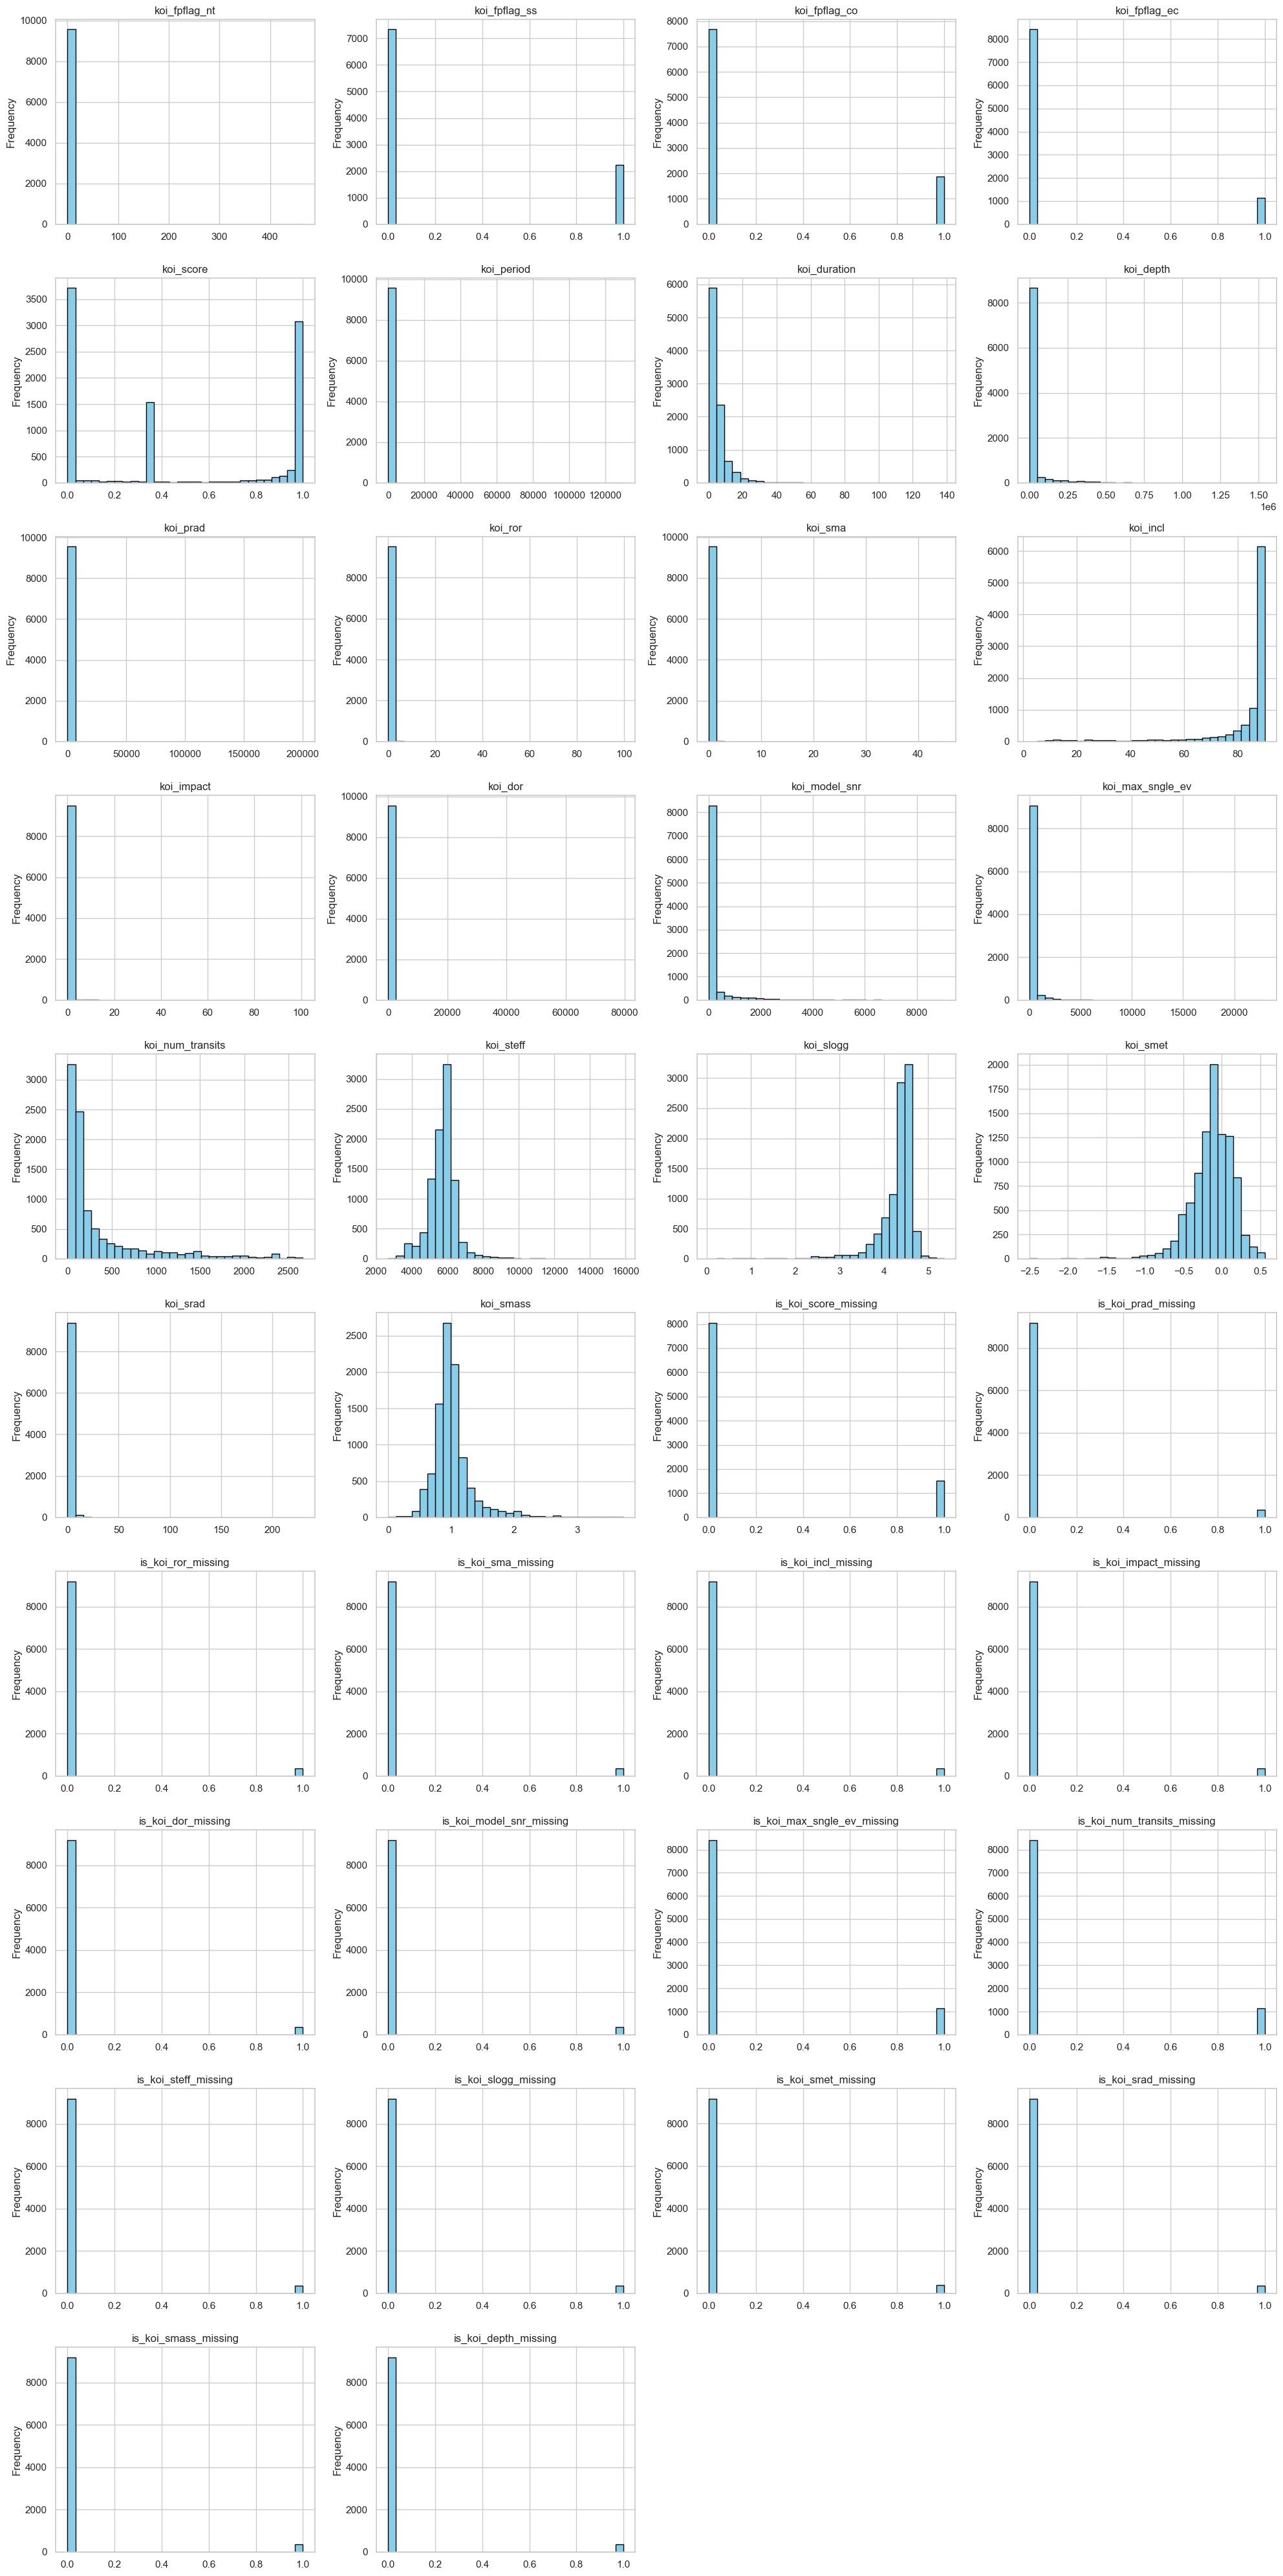

In [18]:
# Optional: switch to seaborn style for nicer plots
sns.set(style="whitegrid")

# Number of features
n_features = len(features.columns)

# Automatically choose number of columns/rows for subplots
n_cols = 4  # adjust if you want wider/narrower grid
n_rows = math.ceil(n_features / n_cols)

# Create figure
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

# Plot each feature
for i, col in enumerate(features.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    # Histogram
    plt.hist(features[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
    
plt.tight_layout()
plt.show()

### We're not removing outliers not a thing for space

## Transforming

In [19]:
# List the columns to log-transform (based on distribution skew)
log_transform_cols = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_ror",
    "koi_sma",
    "koi_dor",
    "koi_model_snr",
    "koi_max_sngle_ev",
    "koi_num_transits",
    "koi_srad"
]

# --- Run the Log Transformation Step ---
for col in log_transform_cols:
    # Create new log-transformed feature (after imputation, before scaling)
    features[f'log_{col}'] = np.log1p(features[col])

print("Log-transformed columns successfully created:")
print(log_transform_cols)


Log-transformed columns successfully created:
['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_ror', 'koi_sma', 'koi_dor', 'koi_model_snr', 'koi_max_sngle_ev', 'koi_num_transits', 'koi_srad']


/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/4268406211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[f'log_{col}'] = np.log1p(features[col])
/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/4268406211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[f'log_{col}'] = np.log1p(features[col])
/var/folders/4x/901qdy4j6zd4zgj58qly6nt40000gr/T/ipykernel_14464/4268406211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

## Scaling

In [20]:
# --- A. Define Columns ---

# 1. Numerical columns to SCALE (final list)
numerical_cols = [

    # Log-transformed heavy-skew variables
    'log_koi_period', 'log_koi_duration', 'log_koi_depth',
    'log_koi_prad', 'log_koi_ror', 'log_koi_sma', 'log_koi_dor',
    'log_koi_model_snr', 'log_koi_max_sngle_ev', 'log_koi_num_transits',
    'log_koi_srad',

    # Normal-ish variables to scale directly
    'koi_incl', 'koi_impact', 'koi_score',
    'koi_steff', 'koi_slogg', 'koi_smet', 'koi_smass'
]

# 2. Binary/Flag columns to leave untouched
binary_cols = [
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
] + new_missing_flag_cols  # keep your dynamically created missing flags

# --- B. Apply Standardization (Z-Score) ---
scaler = StandardScaler()

# Scale ONLY the selected numerical columns
scaled_numerical_data = scaler.fit_transform(features[numerical_cols])

# Back into DataFrame
scaled_df = pd.DataFrame(
    scaled_numerical_data,
    columns=numerical_cols,
    index=features.index
)

# Combine scaled numerical features + unscaled binary features
X = pd.concat([scaled_df, features[binary_cols]], axis=1)

print("--- Final Feature Matrix (X) Successfully Created ---")
print(f"Total features in X: {X.shape[1]}")


--- Final Feature Matrix (X) Successfully Created ---
Total features in X: 38


In [21]:
# Check for any remaining NaNs in the final feature matrix X
print("Columns in X with residual NaNs:")
print(X.isnull().sum().loc[X.isnull().sum() > 0])

Columns in X with residual NaNs:
Series([], dtype: int64)


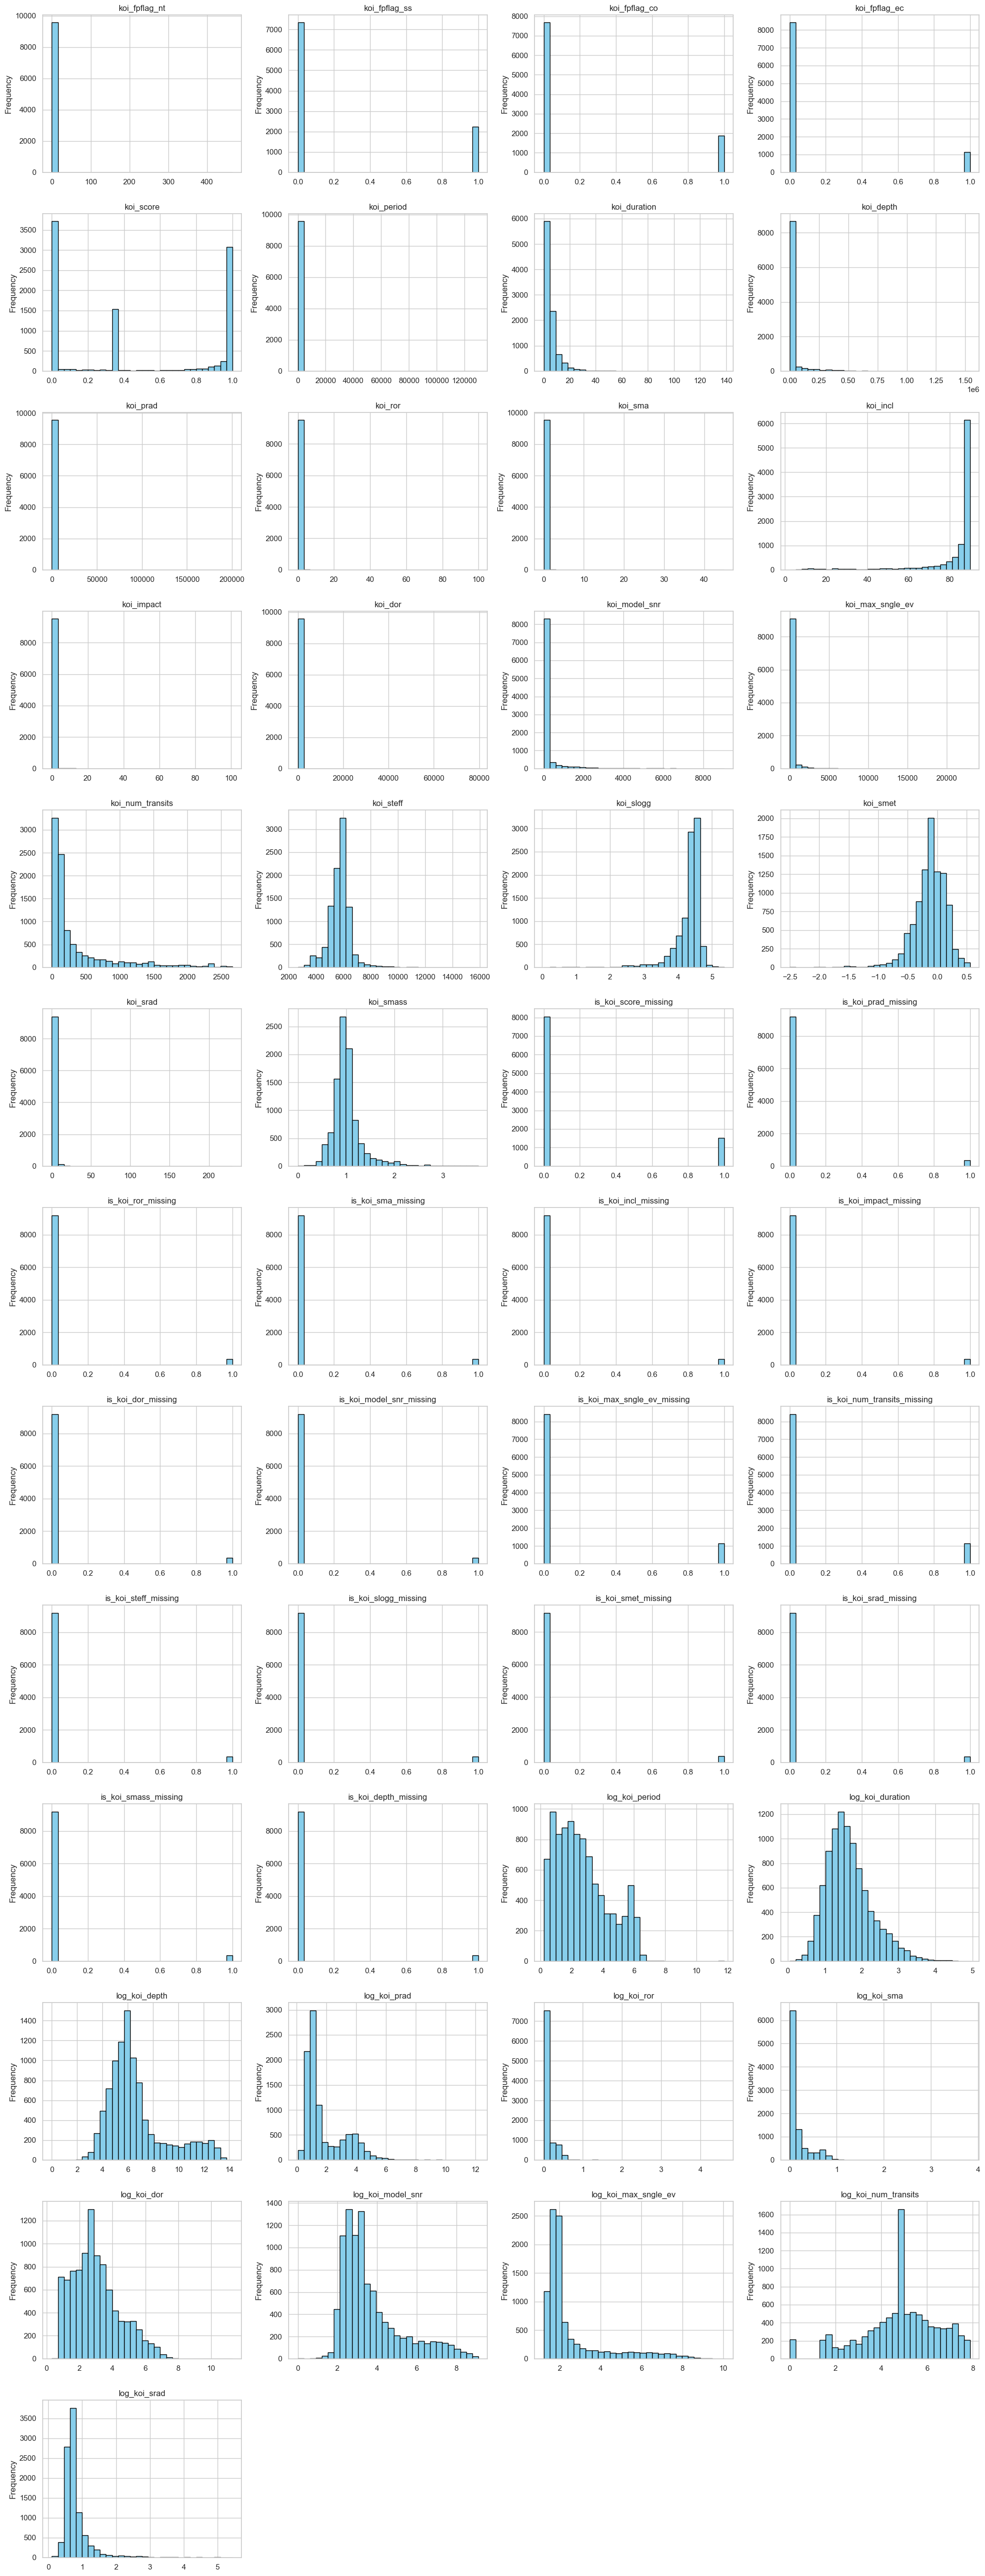

In [95]:
# Optional: switch to seaborn style for nicer plots
sns.set(style="whitegrid")

# Number of features
n_features = len(features.columns)

# Automatically choose number of columns/rows for subplots
n_cols = 4  # adjust if you want wider/narrower grid
n_rows = math.ceil(n_features / n_cols)

# Create figure
plt.figure(figsize=(5 * n_cols, 4 * n_rows))

# Plot each feature
for i, col in enumerate(features.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    # Histogram
    plt.hist(features[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('Frequency')
    
plt.tight_layout()
plt.show()

### encode targets into 3 classes

In [22]:

# Assuming X is your final scaled feature matrix
# Assuming original_data is the DataFrame with the 'koi_disposition' column (text labels)

# 1. Target Variable Encoding (y)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(original_data['koi_disposition'])

# Map the encoded numbers back to labels for future reference
# THIS IS CRUCIAL FOR INTERPRETATION
target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Target Encoding Map (Multi-Class):")
print(target_mapping)

Target Encoding Map (Multi-Class):
{'CANDIDATE': np.int64(0), 'CONFIRMED': np.int64(1), 'FALSE POSITIVE': np.int64(2)}


### split data

In [23]:
# 2. Data Splitting
# Use 80% for training and 20% for testing, and stratify to maintain 
# the same proportion of target classes in both sets.
# Note: X is the final features matrix, and y is the encoded target array
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensures class balance is maintained
)

print("\n--- Data Preparation Complete ---")
print(f"Training Features (X_train) Shape: {X_train.shape}")
print(f"Testing Features (X_test) Shape: {X_test.shape}")


--- Data Preparation Complete ---
Training Features (X_train) Shape: (7651, 38)
Testing Features (X_test) Shape: (1913, 38)


### Checking class balance
 we can see this isn't balanced. Much higher percentage of class 2 false positive and model will prioritize the majority classes. Will have a high overall accuracy but then perform poorly on the minority class. 

In [24]:
# Assuming y_train is your encoded target variable training set

# 1. Get counts for each class
class_counts = pd.Series(y_train).value_counts().sort_index()

# 2. Get percentages for each class
class_percentages = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100

# 3. Create a summary DataFrame for easy viewing
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages.round(2)
})

print("Class Distribution in y_train:")
# Reminder: The labels (0, 1, 2) correspond to your target encoding map 
# (e.g., 0=CANDIDATE, 1=CONFIRMED, 2=FALSE POSITIVE)
print(class_distribution)

Class Distribution in y_train:
   Count  Percentage
0   1583       20.69
1   2197       28.72
2   3871       50.59


### Create pie chart or some plot make it look nicer

## Model training 

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=500, 
    random_state=42,
    C=1.0, 
    # Add the class_weight parameter
    class_weight='balanced')

# 2. Train the Model (The rest of your code remains the same)
logreg_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=500,
                   multi_class='multinomial', random_state=42)

In [93]:
# 3. Make predictions on the test set
y_pred_logreg = logreg_model.predict(X_test)

# 4. Evaluate Performance
accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Overall Test Accuracy: {accuracy:.4f}")


Logistic Regression Overall Test Accuracy: 0.9127


In [94]:
print(classification_report(y_test, y_pred_logreg, digits=3))

              precision    recall  f1-score   support

           0      0.769     0.856     0.810       396
           1      0.881     0.847     0.864       549
           2      0.998     0.973     0.985       968

    accuracy                          0.913      1913
   macro avg      0.882     0.892     0.886      1913
weighted avg      0.917     0.913     0.914      1913



<Figure size 800x800 with 0 Axes>

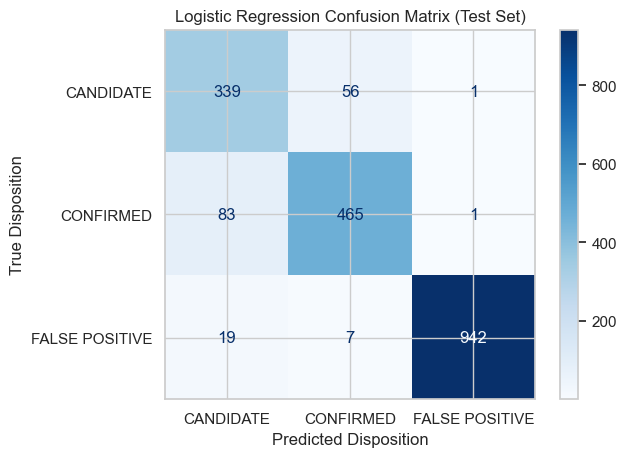

In [88]:
# 1. Define the True Display Labels from your target encoding map
# Assuming the labels were mapped alphabetically: [CANDIDATE, CONFIRMED, FALSE POSITIVE]
# You should verify the exact order from your 'target_mapping' dictionary output.
display_labels = ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'] 

# 2. Calculate the Confusion Matrix
# Use the correct test set predictions and true labels
cm = metrics.confusion_matrix(y_test, y_pred_logreg)

# 3. Create the enhanced plot
plt.figure(figsize=(8, 8)) 

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

# Use 'Blues' or another suitable colormap and set a title
disp.plot(cmap=plt.cm.Blues, values_format='d') 
disp.ax_.set_title('Logistic Regression Confusion Matrix (Test Set)')

# Optional: Add axis labels for better clarity
disp.ax_.set_xlabel("Predicted Disposition")
disp.ax_.set_ylabel("True Disposition")

plt.savefig('logreg_confusion_matrix.png')


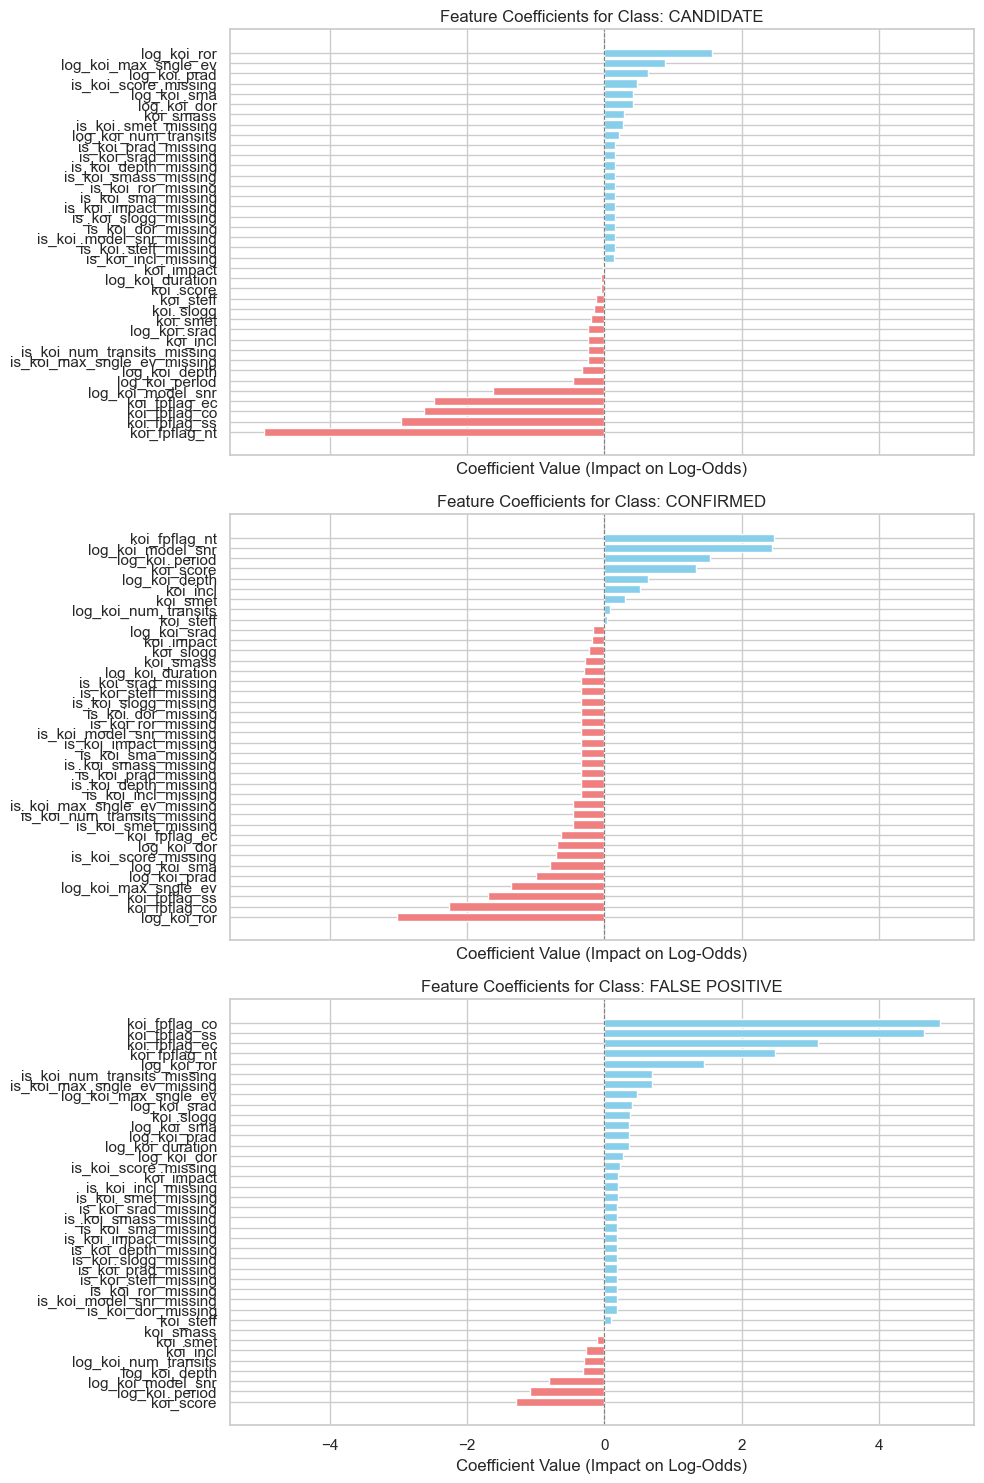

In [85]:
# Assuming logreg_model is your trained Logistic Regression model
# Assuming X is your final feature matrix (column names are needed)

# Get the feature names from your final matrix X
feature_names = X.columns

# Get the coefficients (logreg_model.coef_ returns a matrix: [n_classes, n_features])
coefficients = logreg_model.coef_

# Get the class names from your mapping (e.g., ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'])
class_names = list(target_mapping.keys())

# Plotting the coefficients
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15), sharex=True)

for i, class_label in enumerate(class_names):
    ax = axes[i]
    # Sort coefficients for better visualization
    sorted_indices = np.argsort(coefficients[i])
    sorted_coefs = coefficients[i][sorted_indices]
    sorted_features = [feature_names[j] for j in sorted_indices]
    
    # Plot the coefficients
    ax.barh(sorted_features, sorted_coefs, color=np.where(sorted_coefs > 0, 'skyblue', 'lightcoral'))
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Feature Coefficients for Class: {class_label}')
    ax.set_xlabel('Coefficient Value (Impact on Log-Odds)')

plt.tight_layout()

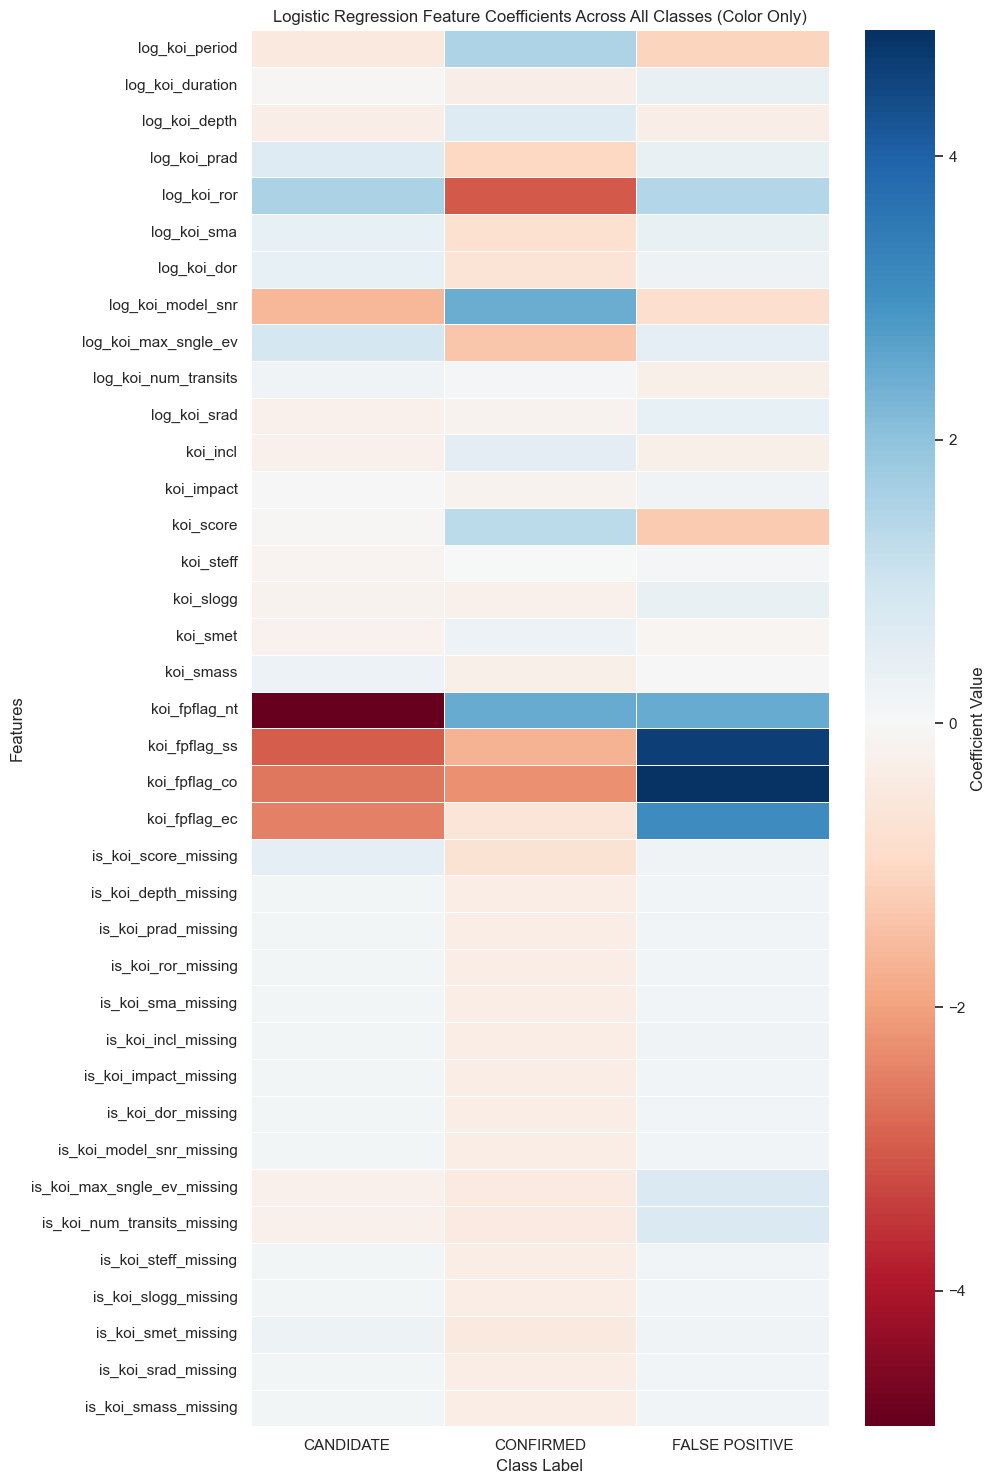

In [87]:
# --- Setup: Convert the coefficients into a structured DataFrame ---
# Assumes coefficients, feature_names, and class_names are already defined
coef_df = pd.DataFrame(
    coefficients.T, # Transpose for (Features x Classes) layout
    index=feature_names,
    columns=class_names
)

# --- Visualization: Create the Heatmap without numbers (annotations) ---
plt.figure(figsize=(10, 15))

# The key change: annot=False
sns.heatmap(
    coef_df,
    annot=False, # Set to False to remove numerical annotations
    cmap='RdBu',
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Coefficient Value'} # Label the color bar
)

plt.title('Logistic Regression Feature Coefficients Across All Classes (Color Only)')
plt.ylabel('Features')
plt.xlabel('Class Label')

plt.tight_layout()
plt.savefig('coefficients_heatmap_color_only.png')

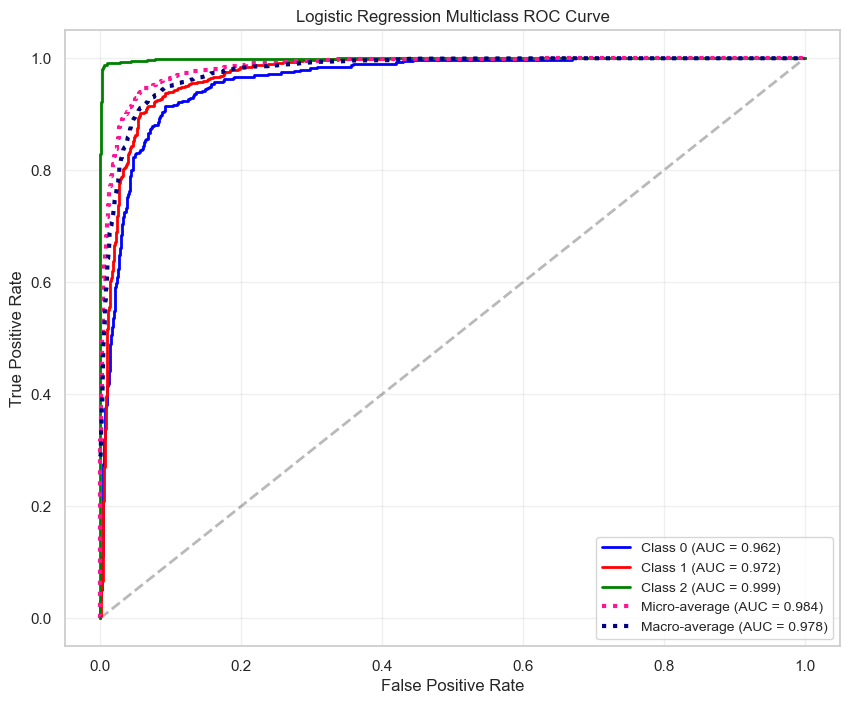

<Figure size 640x480 with 0 Axes>

In [91]:
# Assume y_test and X_test are defined
# Get the list of classes
classes = np.unique(y_test)
n_classes = len(classes)

# Convert y_test to one-hot / binarized format
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_score = logreg_model.predict_proba(X_test)  # returns list of arrays for multiclass

# If predict_proba returns a list of arrays, stack into a single array
if isinstance(y_score, list):
    y_score = np.vstack([prob for prob in y_score])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro and macro averages
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Multiclass ROC Curve')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

plt.savefig('logreg_ROC.png')


1️⃣ Train Logistic Regression as the baseline
Use:
No or minimal hyperparameter tuning
StandardScaler if features vary in scale
Report: accuracy, F1, ROC AUC
This will likely perform okay but not great.
Your write-up can say:
Logistic Regression provides a linear baseline but cannot capture nonlinear interactions among astrophysical variables such as transit depth, stellar radius, or SNR.

### XGBoost with all features to see which one is most important 

In [34]:
#target dataframe with the classes assigned to numbers 
# target_XBG

In [35]:
# label_encoder = LabelEncoder()
# target_XGB = label_encoder.fit_transform(original_data['koi_disposition'])

# # Map the encoded numbers back to labels for future reference
# # THIS IS CRUCIAL FOR INTERPRETATION
# target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print("Target Encoding Map (Multi-Class):")
# print(target_mapping)

In [36]:
# #all features 
# all_features_XGB = (original_data).drop(['koi_disposition'], axis=1)
# display(all_features_XGB)

In [37]:
# all_features_XGB.info()

In [38]:
# all_features_XGB = all_features_XGB.select_dtypes(exclude=['object'])

In [39]:
# X_train, X_test, y_train, y_test = train_test_split(
#     all_features_XGB,
#     target_XGB,
#     test_size=0.2,
#     random_state=42,
#     stratify=target_XGB  # only for classification
# )

In [40]:
# all_features_model = xgb.XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",   # required to silence warnings
#     tree_method="hist"       # fast and recommended
# )

# all_features_model.fit(X_train, y_train)

In [41]:
# # xgb.plot_importance(all_features_model, max_num_features=len(all_features_model.feature_names_in_))

# plt.figure(figsize=(10, 50))  # Increase height a LOT
# xgb.plot_importance(all_features_model, max_num_features=22)
# plt.tight_layout()
# plt.show()



## XGBoost with hand selected features 

No need to scale or remove missing values from data set model will do that for you. We just need to adjust the weights later in fine tuning due to class imbalance.

In [42]:
# target_XGB = original_data[['koi_disposition']]

Assign values to the classes 

In [43]:
# label_encoder = LabelEncoder()
# target_XGB = label_encoder.fit_transform(original_data['koi_disposition'])

# # Map the encoded numbers back to labels for future reference
# # THIS IS CRUCIAL FOR INTERPRETATION
# target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print("Target Encoding Map (Multi-Class):")
# print(target_mapping)

In [44]:
# feature_XGB = original_data[[

#     # Vetting flags
#     "koi_fpflag_nt",
#     "koi_fpflag_ss",
#     "koi_fpflag_co",
#     "koi_fpflag_ec",

#     # Score
#     "koi_score",

#     # Transit / fit parameters
#     "koi_period",
#     "koi_duration",
#     "koi_depth",
#     "koi_prad",
#     "koi_ror",
#     "koi_sma",
#     "koi_incl",
#     "koi_impact",
#     "koi_dor",

#     # Strength / detection stats
#     "koi_model_snr",
#     "koi_max_single_ev",
#     "koi_num_transits",

#     # Stellar parameters
#     "koi_steff",
#     "koi_slogg",
#     "koi_smet",
#     "koi_srad",
#     "koi_smass",
# ]]

In [45]:
# X_train, X_test, y_train, y_test = train_test_split(
#     feature_XGB,
#     target_XGB,
#     test_size=0.2,
#     random_state=42,
#     stratify=target_XGB  # only for classification
# )

In [46]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)

XGB_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",   # required to silence warnings
    tree_method="hist"       # fast and recommended
)

XGB_model.fit(X_train, y_train, sample_weight=weights)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
y_pred_XGB = XGB_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_XGB)
print("Accuracy:", accuracy)


Accuracy: 0.9268165185572399


In [58]:
print(classification_report(y_test, y_pred_XGB, digits=3))

              precision    recall  f1-score   support

           0      0.804     0.859     0.830       396
           1      0.901     0.878     0.889       549
           2      0.996     0.982     0.989       968

    accuracy                          0.927      1913
   macro avg      0.900     0.906     0.903      1913
weighted avg      0.929     0.927     0.928      1913



Text(0, 0.5, 'True Disposition')

<Figure size 800x800 with 0 Axes>

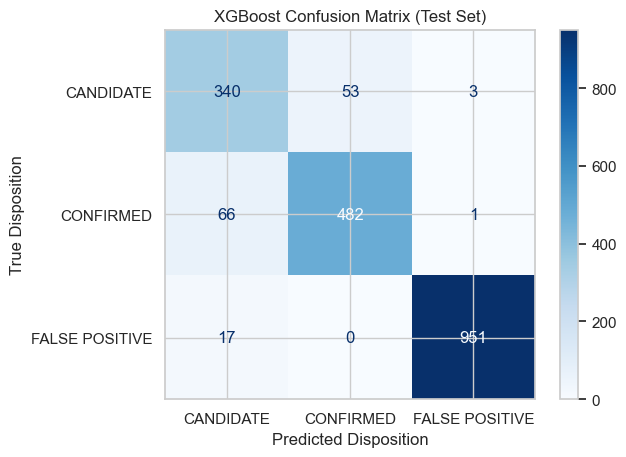

In [49]:
# 1. Define the True Display Labels from your target encoding map
# Assuming the labels were mapped alphabetically: [CANDIDATE, CONFIRMED, FALSE POSITIVE]
# You should verify the exact order from your 'target_mapping' dictionary output.
display_labels = ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'] 

# 2. Calculate the Confusion Matrix
# Use the correct test set predictions and true labels
cm = metrics.confusion_matrix(y_test, y_pred_XGB)

# 3. Create the enhanced plot
plt.figure(figsize=(8, 8)) 

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

# Use 'Blues' or another suitable colormap and set a title
disp.plot(cmap=plt.cm.Blues, values_format='d') 
disp.ax_.set_title('XGBoost Confusion Matrix (Test Set)')

# Optional: Add axis labels for better clarity
disp.ax_.set_xlabel("Predicted Disposition")
disp.ax_.set_ylabel("True Disposition")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

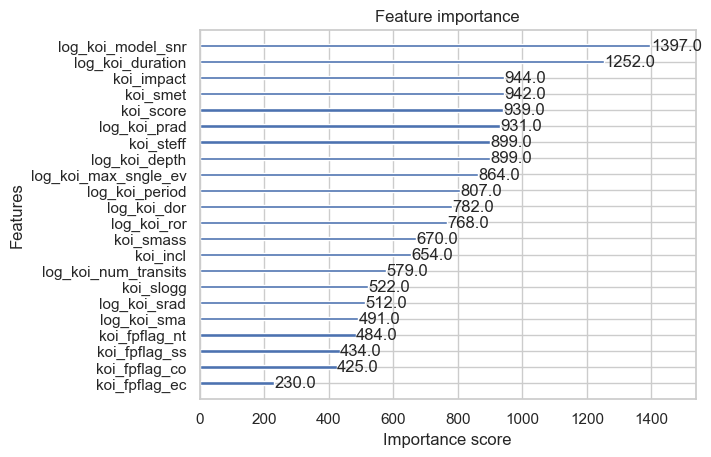

In [72]:
xgb.plot_importance(XGB_model, max_num_features=22)

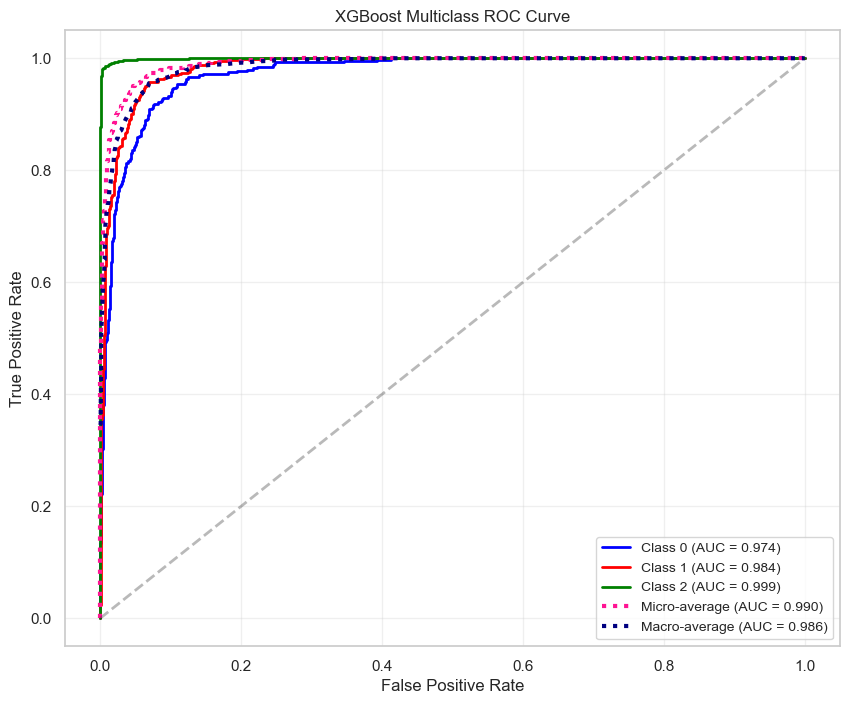

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Assume y_test and X_test are defined
# Get the list of classes
classes = np.unique(y_test)
n_classes = len(classes)

# Convert y_test to one-hot / binarized format
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_score = XGB_model.predict_proba(X_test)  # returns list of arrays for multiclass

# If predict_proba returns a list of arrays, stack into a single array
if isinstance(y_score, list):
    y_score = np.vstack([prob for prob in y_score])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro and macro averages
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Multiclass ROC Curve')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()


### Cross validation

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# Adjust: Change objective to 'multi:softmax', eval_metric to 'mlogloss', and set num_class=3
xgb_model = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    tree_method='hist',
    num_class=3  # Set the number of classes
)

param_dist = {
    'n_estimators': np.arange(200, 900, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=250,          # number of random combinations to try
    scoring='f1_macro',  # or 'f1', 'accuracy'
    cv=5,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best ROC AUC:", random_search.best_score_)


Fitting 5 folds for each of 250 candidates, totalling 1250 fits
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=8, min_child_weight=5, n_estimators=400, reg_alpha=0.01, reg_lambda=10, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=8, min_child_weight=5, n_estimators=400, reg_alpha=0.01, reg_lambda=10, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=8, min_child_weight=5, n_estimators=400, reg_alpha=0.01, reg_lambda=10, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, min_child_weight=7, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.8, gamma=0.4, learn

### Best XGBoost

In [52]:
# 1. Compute weights for class imbalance
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize the model with best parameters and CORRECT multi-class settings
best_XGB_model = XGBClassifier(
    # Unpack all best parameters found by RandomizedSearchCV
    **random_search.best_params_, 
    
    # CRITICAL FIXES for 3-class classification
    objective='multi:softmax',
    eval_metric='mlogloss',
    num_class=3, # Must specify the count of your classes (0, 1, 2)
    
    # Standard settings (can be kept or removed if included in best_params_)
    tree_method='hist' 
)

# 3. Train the model using the training data and sample weights
best_XGB_model.fit(X_train, y_train, sample_weight=weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(700), n_jobs=None,
              num_class=3, ...)

In [53]:
y_pred_best_XGB = best_XGB_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best_XGB)
print("Accuracy:", accuracy)

Accuracy: 0.9320439100888657


In [59]:
print(classification_report(y_test, y_pred_best_XGB, digits=3))

              precision    recall  f1-score   support

           0      0.819     0.866     0.842       396
           1      0.909     0.891     0.900       549
           2      0.995     0.982     0.989       968

    accuracy                          0.932      1913
   macro avg      0.907     0.913     0.910      1913
weighted avg      0.934     0.932     0.933      1913



Text(0, 0.5, 'True Disposition')

<Figure size 800x800 with 0 Axes>

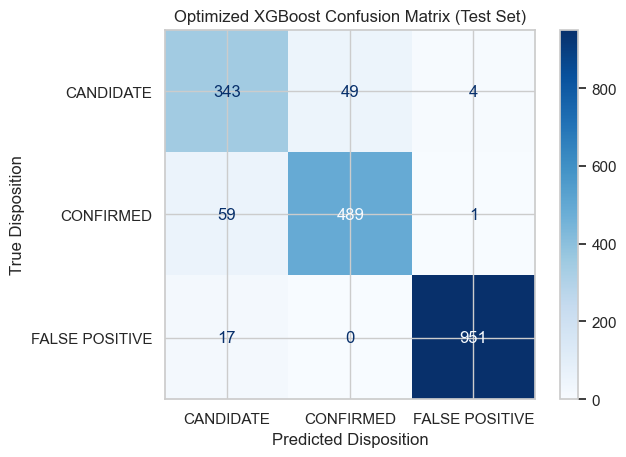

In [62]:
# 1. Define the True Display Labels from your target encoding map
# Assuming the labels were mapped alphabetically: [CANDIDATE, CONFIRMED, FALSE POSITIVE]
# You should verify the exact order from your 'target_mapping' dictionary output.
display_labels = ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE'] 

# 2. Calculate the Confusion Matrix
# Use the correct test set predictions and true labels
cm = metrics.confusion_matrix(y_test, y_pred_best_XGB)

# 3. Create the enhanced plot
plt.figure(figsize=(8, 8)) 

disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

# Use 'Blues' or another suitable colormap and set a title
disp.plot(cmap=plt.cm.Blues, values_format='d') 
disp.ax_.set_title('Optimized XGBoost Confusion Matrix (Test Set)')

# Optional: Add axis labels for better clarity
disp.ax_.set_xlabel("Predicted Disposition")
disp.ax_.set_ylabel("True Disposition")

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

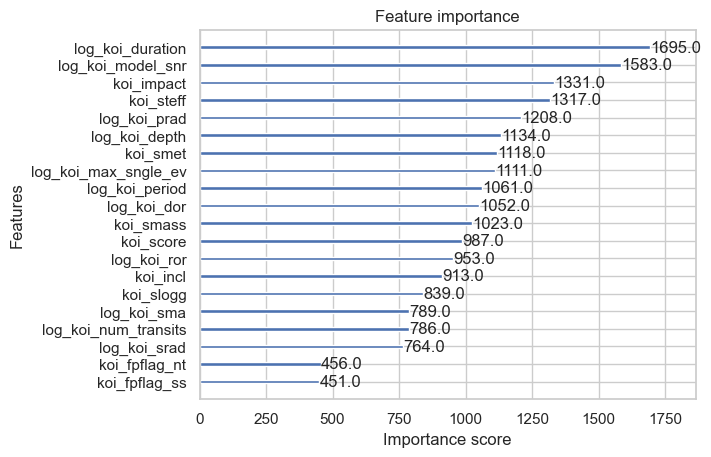

In [67]:
xgb.plot_importance(best_XGB_model, max_num_features=20)

In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Convert y_test to one-hot format
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_prob = best_XGB_model.predict_proba(X_test)

# Compute macro and micro ROC AUC
auc_micro = roc_auc_score(y_test_bin, y_prob, average='micro')
auc_macro = roc_auc_score(y_test_bin, y_prob, average='macro')

print("Micro-average ROC AUC:", auc_micro)
print("Macro-average ROC AUC:", auc_macro)



Micro-average ROC AUC: 0.9901518457501416
Macro-average ROC AUC: 0.9852876309295598


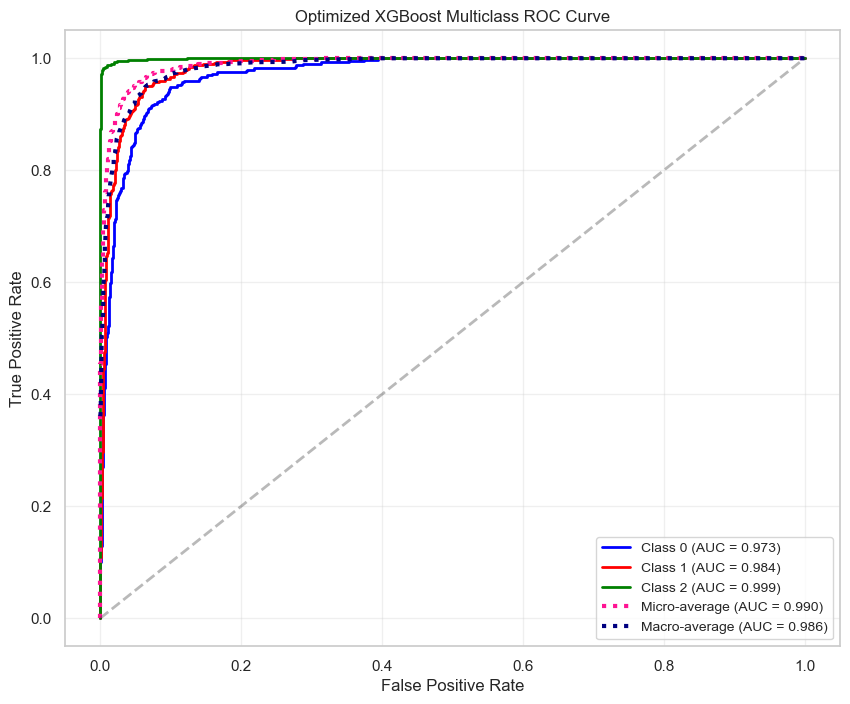

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Assume y_test and X_test are defined
# Get the list of classes
classes = np.unique(y_test)
n_classes = len(classes)

# Convert y_test to one-hot / binarized format
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_score = best_XGB_model.predict_proba(X_test)  # returns list of arrays for multiclass

# If predict_proba returns a list of arrays, stack into a single array
if isinstance(y_score, list):
    y_score = np.vstack([prob for prob in y_score])

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro and macro averages
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized XGBoost Multiclass ROC Curve')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()
